Logistic Regression is a supervised machine learning algorithm used for classification problems, especially when the output is binary (e.g., yes/no, 0/1). Instead of predicting a continuous value like linear regression, it predicts the probability that a data point belongs to a particular class using a function called the sigmoid (logistic) function, which maps values between 0 and 1.

The model estimates the relationship between input features and the probability of an outcome, and then applies a threshold (commonly 0.5) to assign a final class label. Despite its name, logistic regression is used for classification tasks and is valued for its simplicity, interpretability, and effectiveness on linearly separable data.

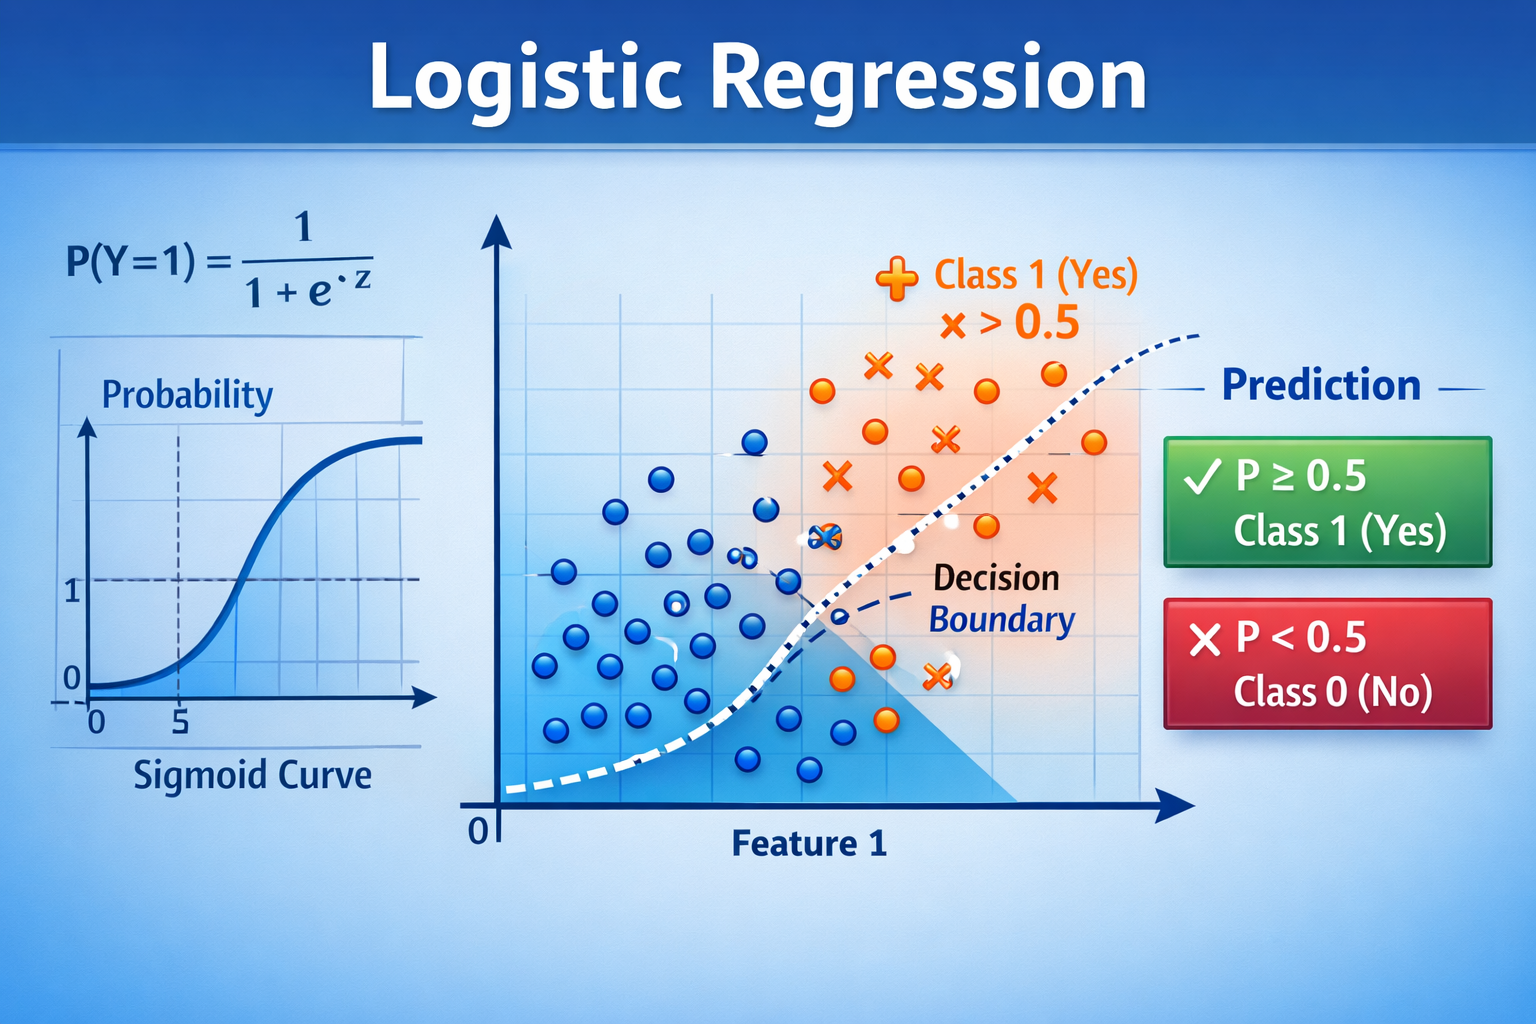

Phase 1 – Data Cleaning & Exploratory Analysis

This phase focuses on preparing the dataset for modeling by ensuring data quality and gaining initial insights. It involves handling missing values, correcting inconsistencies, and transforming features into suitable formats for analysis. Additionally, exploratory data analysis (EDA) is performed to identify patterns, relationships, and trends within the data, helping to understand feature behavior and guide subsequent modeling decisions.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from textwrap import wrap

# Import data from CSV
data_df = pd.read_csv('/content/diabetes_data_upload.csv')

# Convert data frame to numpy array
data = data_df.to_numpy()

data_df[:10]

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,Positive
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive
5,55,Male,Yes,Yes,No,Yes,Yes,No,Yes,Yes,No,Yes,No,Yes,Yes,Yes,Positive
6,57,Male,Yes,Yes,No,Yes,Yes,Yes,No,No,No,Yes,Yes,No,No,No,Positive
7,66,Male,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,No,Yes,Yes,No,No,Positive
8,67,Male,Yes,Yes,No,Yes,Yes,Yes,No,Yes,Yes,No,Yes,Yes,No,Yes,Positive
9,70,Male,No,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,No,No,No,Yes,No,Positive


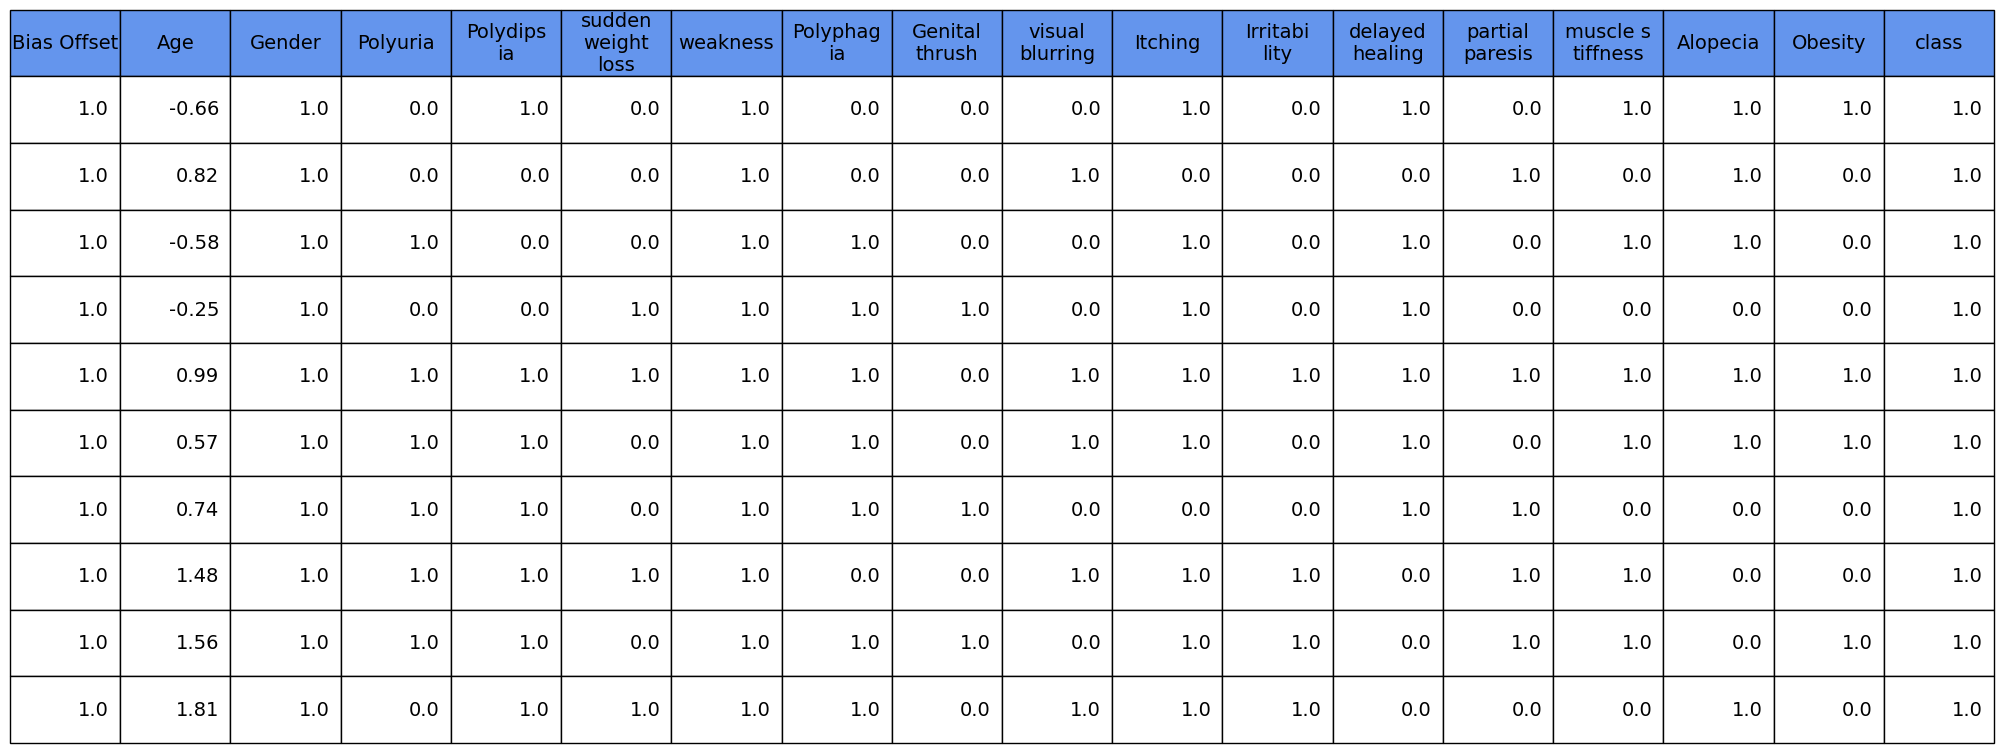

In [ ]:
# reset data array incase cell is ran multiple times
data = data_df.to_numpy()

# Calculate average
age_mu = sum(data[:,0])/len(data[:,0])

# Calculate standard deviation
age_sigma = np.sqrt((1/len(data[:,0]))*sum((data[:,0] - age_mu)**2))

# Calculate standardized age
age_stand = (data[:,0] - age_mu)/age_sigma

# Replace the age with the standardized age
data[:,0] = age_stand

# Change text to a 1 or 0
for i in range(len(data[:,0])):
    for j, value in enumerate(data[i,:]):
        # Change true, yes, positive, and male to a 1
        if (value == 'True') or (value == 'Yes') or (value == 'Positive') or (value == 'Male'):
            data[i,j] = 1
        # Change no, negative, female to a 0
        elif (value == 'No') or (value == 'Negative') or (value == 'Female'):
            data[i,j] = 0

# Add a column of ones for the bias
data = np.c_[np.ones(data.shape[0]), data]

# Round the data to fit the table
data = np.round(np.array(data, np.float32), 2)


# Display data in a table
fig, ax = plt.subplots()
fig.patch.set_visible(False)
ax.axis('off')
ax.axis('tight')

# Add column names
label = ['\n'.join(wrap(l, 8)) for l in data_df.columns]

# Name the bias column of 1s
label = ["Bias Offset"] + label

table = plt.table(cellText = data[:10,:],
                  colLabels = label,
                  colColours=["cornflowerblue"]*len(data[0,:]),
                  loc = 'center')

table.scale(4,4)
table.auto_set_font_size(False)
table.set_fontsize(14)

Phase 2 – Model Training

In this phase, a Logistic Regression model is trained using the training subset of the dataset. The algorithm learns the relationship between the input features and the target variable by estimating parameters that best map feature values to class probabilities. This process enables the model to identify patterns in the data and prepare for accurate classification on unseen samples.

In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(data[:,:-1], data[:,-1], train_size=0.75, random_state=42)
model = LogisticRegression(penalty='l2')
model.fit(X_train, y_train)


LogisticRegression()

Phase 3 – Model Testing

In this phase, the trained Logistic Regression model is evaluated on unseen test data to assess its ability to generalize beyond the training set. Performance is measured using metrics such as accuracy, precision, recall, and F1-score, along with a confusion matrix to analyze class-wise prediction outcomes and identify potential misclassifications.

Logistic Regression Model Performance Metrics
Accuracy : 0.93
Precision: 0.94
Recall   : 0.95
F1 Score : 0.95

Classification Report:

              precision    recall  f1-score   support

    Negative       0.91      0.89      0.90        46
    Positive       0.94      0.95      0.95        84

    accuracy                           0.93       130
   macro avg       0.93      0.92      0.92       130
weighted avg       0.93      0.93      0.93       130



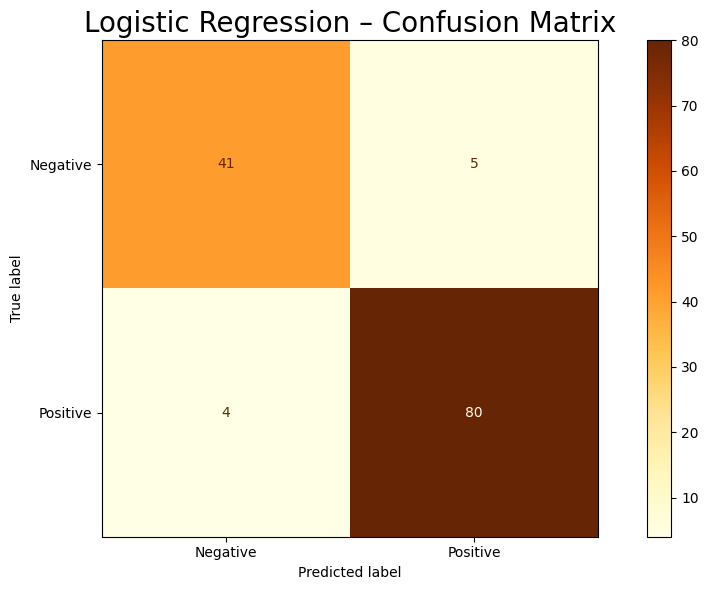

In [ ]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    f1_score,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score
)

# Predict on test set
y_hat = model.predict(X_test)

# ---- Metrics ----
acc  = accuracy_score(y_test, y_hat)
prec = precision_score(y_test, y_hat)
rec  = recall_score(y_test, y_hat)
f1   = f1_score(y_test, y_hat)

print("Logistic Regression Model Performance Metrics")
print(f"Accuracy : {acc:.2f}")
print(f"Precision: {prec:.2f}")
print(f"Recall   : {rec:.2f}")
print(f"F1 Score : {f1:.2f}\n")

# Detailed classification report
print("Classification Report:\n")
print(classification_report(y_test, y_hat, target_names=["Negative", "Positive"]))

# ---- Confusion Matrix Visualization ----
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.set_title("Logistic Regression – Confusion Matrix", fontsize=20)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_hat,
    display_labels=["Negative", "Positive"],
    cmap="YlOrBr",          # keep your original colormap
    colorbar=True,
    ax=ax
)

plt.tight_layout()
plt.show()

Phase 4 – Model Comparison & Interpretation

In this phase, model performance is analyzed by comparing evaluation metrics across different approaches to assess effectiveness. The results are interpreted to identify strengths, weaknesses, and potential issues such as bias or overfitting. Based on these insights, decisions are made regarding model improvements, including tuning parameters or exploring alternative models to enhance overall performance.

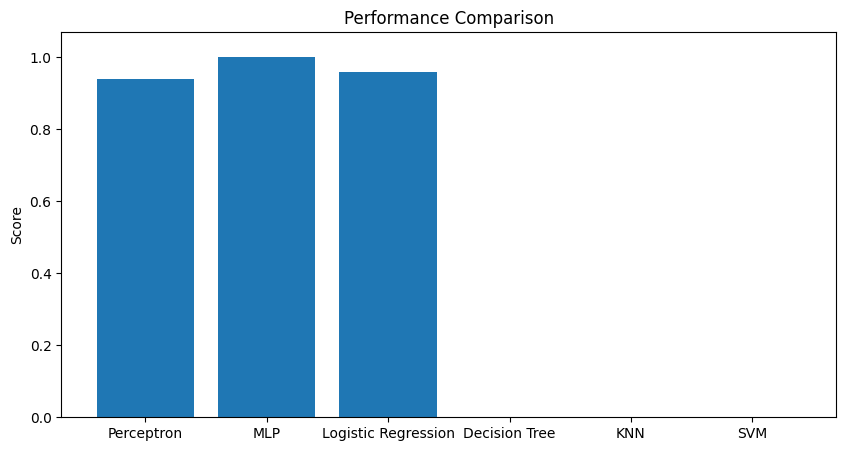

In [ ]:
model_scores = {
    "Perceptron": 0.94,
    "MLP": 1.00,
    "Logistic Regression": 0.96,
    "Decision Tree": None,
    "KNN": None,
    "SVM": None
}
names = list(model_scores.keys())
values = [v if v is not None else 0 for v in model_scores.values()]
plt.figure(figsize=(10,5))
plt.bar(names, values)
plt.title("Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.07)
plt.show()
